# IEOR E4004 – Project I: Eliminating Child Care Deserts in NYC
### Spring 2026

**Notebook structure:**
1. Data Cleaning & Parameter Estimation
2. Problem I — Budgeting (Idealistic Scenario)
3. Problem II — Realistic Expansion + Distance Constraints

---
## Section 1 — Data Cleaning & Parameter Estimation

### Data issues identified and resolved

| # | Issue | Fix |
|---|---|---|
| 1 | 169 missing lat/lon in childcare | Imputed from same-zip median; fallback to potential_locations centroid |
| 2 | 32 extra zips in population with no employment/income data | Dropped — cannot define desert threshold without both |
| 3 | **FDC/GFDC facilities store all capacity in `children_capacity`** | Count `children_capacity` for FDC/GFDC as 0-5 eligible slots |
| 4 | Desert threshold is a strict inequality (`slots <= threshold×pop`) | Minimum slots to exit = `ceil(threshold × pop)` (with `>= ` constraint in model) |
| 5 | Under-5 NYC policy applies to all zips, not just deserts | Applied independently as a separate hard constraint |
| 6 | 4 zips have zero existing facilities | Expansion terms set to zero; new builds only |
| 7 | 1 zip has zero child population | Excluded from optimizer constraints |
| 8 | 4 facilities: `floor(0.20 × n) = 0` | Excluded from Problem II expansion set |

### Key insight on existing under-5 slots (Issue 3)

NYC regulates three facility program types in this dataset:
- **SACC** (School Age Child Care): stores under-5 capacity correctly in `infant_capacity`, `toddler_capacity`, `preschool_capacity` columns.
- **FDC** (Family Day Care) and **GFDC** (Group Family Day Care): licensed to accept children from **6 weeks to 12 years**, but their capacity is recorded entirely in `children_capacity`. The three age-specific columns are zero for these facilities.

Counting only `infant + toddler + preschool` gives just 537 existing 0-5 slots out of 318,355 total — clearly incorrect. Including `children_capacity` for FDC/GFDC brings this to ~70,000, which better reflects actual licensed availability.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from math import radians, cos, sin, asin, sqrt
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

DATA = Path("IEOR4004_ProjectI_Datasets")

childcare  = pd.read_csv(DATA / "child_care_regulated_nyc.csv")
employment = pd.read_csv(DATA / "employment_rate_nyc.csv")
income     = pd.read_csv(DATA / "avg_individual_income_nyc.csv")
population = pd.read_csv(DATA / "population_nyc.csv")
potential  = pd.read_csv(DATA / "potential_locations_nyc.csv")

for df in [childcare, employment, income, population, potential]:
    if 'Unnamed: 0' in df.columns:
        df.drop(columns='Unnamed: 0', inplace=True)

print('Loaded shapes:')
for name, df in [('childcare',childcare),('employment',employment),
                  ('income',income),('population',population),('potential',potential)]:
    print(f'  {name:12s}: {df.shape}')

Loaded shapes:
  childcare   : (7740, 15)
  employment  : (179, 2)
  income      : (179, 2)
  population  : (211, 20)
  potential   : (31100, 3)


In [2]:
# ─────────────────────────────────────────────────────────────
# FIX 1: Impute missing lat/lon (169 rows)
# ─────────────────────────────────────────────────────────────
n_before = childcare[['latitude','longitude']].isnull().sum().sum()

childcare['latitude']  = childcare.groupby('zipcode')['latitude']\
                                   .transform(lambda x: x.fillna(x.median()))
childcare['longitude'] = childcare.groupby('zipcode')['longitude']\
                                   .transform(lambda x: x.fillna(x.median()))

pot_centroids = (potential.groupby('zipcode')[['latitude','longitude']]
                           .median()
                           .rename(columns={'latitude':'_lat','longitude':'_lon'}))
childcare = childcare.merge(pot_centroids, on='zipcode', how='left')
childcare['latitude']  = childcare['latitude'].fillna(childcare['_lat'])
childcare['longitude'] = childcare['longitude'].fillna(childcare['_lon'])
childcare.drop(columns=['_lat','_lon'], inplace=True)

# Drop the single zero-capacity facility
childcare = childcare[childcare['total_capacity'] > 0].reset_index(drop=True)

print(f'Lat/Lon nulls: {n_before} → {childcare[["latitude","longitude"]].isnull().sum().sum()}')
print(f'Facilities after dropping zero-capacity: {len(childcare)}')
print(f'\nProgram types: {childcare["program_type"].value_counts().to_dict()}')

Lat/Lon nulls: 338 → 0
Facilities after dropping zero-capacity: 7739

Program types: {'GFDC': 5468, 'SACC': 1538, 'FDC': 733}


In [3]:
# ─────────────────────────────────────────────────────────────
# FIX 3: Correctly count existing under-5 slots
#
# SACC facilities:    0-5 slots = infant + toddler + preschool
# FDC/GFDC facilities: licensed for ages 6 weeks–12 years,
#                      but capacity is stored in children_capacity.
#                      We count this as 0-5 eligible.
# ─────────────────────────────────────────────────────────────
FDC_TYPES = ['FDC', 'GFDC']

childcare['slots_0_5'] = (
    childcare[['infant_capacity', 'toddler_capacity', 'preschool_capacity']].sum(axis=1)
    + childcare.apply(
        lambda r: r['children_capacity'] if r['program_type'] in FDC_TYPES else 0,
        axis=1
    )
)

print('Existing 0-5 slots by program type:')
print(childcare.groupby('program_type')[['slots_0_5','total_capacity']]
               .sum()
               .assign(frac_0_5=lambda d: (d['slots_0_5']/d['total_capacity']).round(3)))
print(f'\nTotal existing 0-5 slots: {childcare["slots_0_5"].sum():,}')
print(f'Total existing slots:     {childcare["total_capacity"].sum():,}')

Existing 0-5 slots by program type:
              slots_0_5  total_capacity  frac_0_5
program_type                                     
FDC                4337            5589     0.776
GFDC              65022           83309     0.780
SACC                537          229457     0.002

Total existing 0-5 slots: 69,896
Total existing slots:     318,355


In [4]:
# ─────────────────────────────────────────────────────────────
# Build per-zip summary table
# ─────────────────────────────────────────────────────────────
core_zips = set(employment['zipcode']) & set(income['zipcode'])
print(f'Core zips (have employment & income): {len(core_zips)}')
print(f'Dropped from population: {len(set(population["zipcode"])) - len(core_zips)} special-use zips')

pop = (population[population['zipcode'].isin(core_zips)]
                  [['zipcode', '-5', '6-12']].copy())
pop.rename(columns={'-5': 'pop_0_5', '6-12': 'pop_6_12'}, inplace=True)
pop['pop_0_12'] = pop['pop_0_5'] + pop['pop_6_12']

zip_df = pop.merge(employment, on='zipcode').merge(income, on='zipcode')
zip_df.rename(columns={'employment rate': 'emp_rate',
                        'average income':  'avg_income'}, inplace=True)

# Demand classification
zip_df['high_demand'] = (zip_df['emp_rate'] >= 0.60) | (zip_df['avg_income'] <= 60_000)
zip_df['threshold']   = np.where(zip_df['high_demand'], 0.50, 1/3)

# Minimum slots to exit desert (>= because constraint in model is >=)
zip_df['min_slots_total'] = np.ceil(zip_df['threshold'] * zip_df['pop_0_12']).astype(int)

# Under-5 NYC policy (>= 2/3 of pop_0_5)
zip_df['min_slots_0_5'] = np.ceil((2/3) * zip_df['pop_0_5']).astype(int)

# Zero-pop edge case
zero_pop = zip_df['pop_0_12'] == 0
zip_df.loc[zero_pop, ['min_slots_total', 'min_slots_0_5']] = 0

# Aggregate existing slots per zip
agg = childcare.groupby('zipcode').agg(
    exist_total=('total_capacity', 'sum'),
    exist_0_5  =('slots_0_5',     'sum')
).reset_index()

zip_df = zip_df.merge(agg, on='zipcode', how='left')
zip_df['exist_total'] = zip_df['exist_total'].fillna(0).astype(int)
zip_df['exist_0_5']   = zip_df['exist_0_5'].fillna(0).astype(int)

# Gaps and flags
zip_df['gap_total'] = (zip_df['min_slots_total'] - zip_df['exist_total']).clip(lower=0)
zip_df['gap_0_5']   = (zip_df['min_slots_0_5']   - zip_df['exist_0_5']).clip(lower=0)
zip_df['is_desert'] = zip_df['exist_total'] < zip_df['min_slots_total']
zip_df['has_facilities'] = zip_df['zipcode'].isin(set(childcare['zipcode']))
zip_df['skip'] = zero_pop

print(f"\n{'='*52}")
print(f"  Parameter Estimation Summary")
print(f"{'='*52}")
print(f"  Total zip codes              : {len(zip_df)}")
print(f"  High-demand zips             : {zip_df['high_demand'].sum()}")
print(f"  Child care deserts           : {zip_df['is_desert'].sum()}")
print(f"    ↳ High-demand deserts      : {(zip_df['is_desert'] & zip_df['high_demand']).sum()}")
print(f"    ↳ Normal-demand deserts    : {(zip_df['is_desert'] & ~zip_df['high_demand']).sum()}")
print(f"  Zips with NO facilities      : {(~zip_df['has_facilities']).sum()}")
print(f"  Zips skipped (zero pop)      : {zip_df['skip'].sum()}")
print(f"  Existing 0-5 slots (revised) : {zip_df['exist_0_5'].sum():,}")
print(f"  Total slot gap (0-12)        : {zip_df['gap_total'].sum():,}")
print(f"  Under-5 gap (revised)        : {zip_df['gap_0_5'].sum():,}")
print(f"  Non-deserts failing 0-5 rule : {((zip_df['gap_0_5']>0) & ~zip_df['is_desert']).sum()}")

Core zips (have employment & income): 179
Dropped from population: 32 special-use zips

  Parameter Estimation Summary
  Total zip codes              : 179
  High-demand zips             : 96
  Child care deserts           : 160
    ↳ High-demand deserts      : 89
    ↳ Normal-demand deserts    : 71
  Zips with NO facilities      : 4
  Zips skipped (zero pop)      : 1
  Existing 0-5 slots (revised) : 69,800
  Total slot gap (0-12)        : 232,699
  Under-5 gap (revised)        : 273,891
  Non-deserts failing 0-5 rule : 18


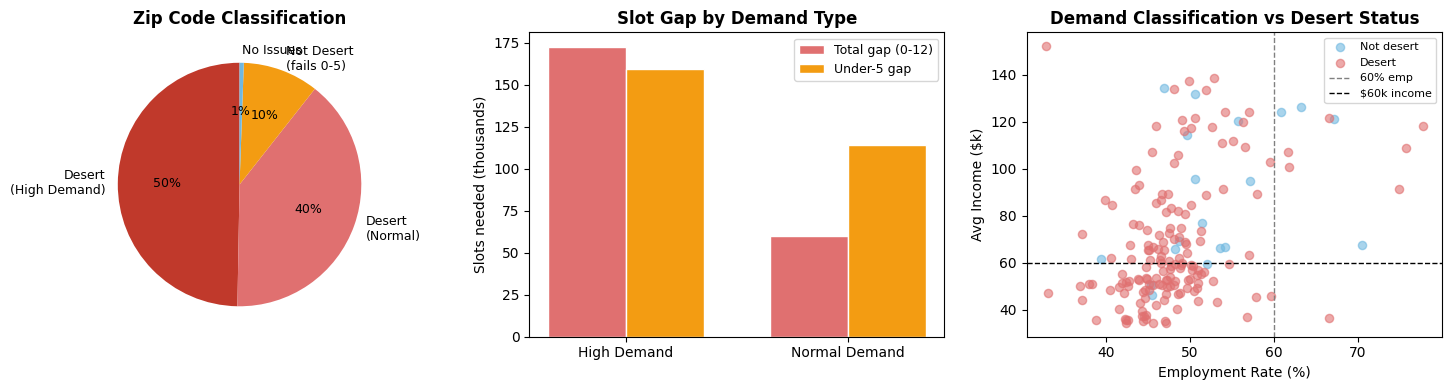

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Classification pie
cats   = ['Desert\n(High Demand)', 'Desert\n(Normal)', 'Not Desert\n(fails 0-5)', 'No Issues']
counts = [
    int((zip_df['is_desert'] & zip_df['high_demand']).sum()),
    int((zip_df['is_desert'] & ~zip_df['high_demand']).sum()),
    int((~zip_df['is_desert'] & (zip_df['gap_0_5']>0)).sum()),
    int((~zip_df['is_desert'] & (zip_df['gap_0_5']==0)).sum()),
]
axes[0].pie(counts, labels=cats, autopct='%1.0f%%',
            colors=['#C0392B','#E07070','#F39C12','#70B8E0'],
            startangle=90, textprops={'fontsize':9})
axes[0].set_title('Zip Code Classification', fontweight='bold')

# 2. Gap comparison: 0-12 vs 0-5, by demand type
labels = ['High Demand', 'Normal Demand']
gap12  = [zip_df[zip_df['high_demand']]['gap_total'].sum(),
          zip_df[~zip_df['high_demand']]['gap_total'].sum()]
gap05  = [zip_df[zip_df['high_demand']]['gap_0_5'].sum(),
          zip_df[~zip_df['high_demand']]['gap_0_5'].sum()]
x = np.arange(2); w = 0.35
axes[1].bar(x-w/2, [g/1000 for g in gap12], w, label='Total gap (0-12)', color='#E07070', edgecolor='white')
axes[1].bar(x+w/2, [g/1000 for g in gap05], w, label='Under-5 gap',      color='#F39C12', edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Slots needed (thousands)')
axes[1].set_title('Slot Gap by Demand Type', fontweight='bold')
axes[1].legend(fontsize=9)

# 3. Scatter: emp rate vs income, colored by desert
dm = zip_df['is_desert']
axes[2].scatter(zip_df[~dm]['emp_rate']*100, zip_df[~dm]['avg_income']/1000,
                alpha=0.6, color='#70B8E0', label='Not desert', s=35)
axes[2].scatter(zip_df[dm]['emp_rate']*100, zip_df[dm]['avg_income']/1000,
                alpha=0.6, color='#E07070', label='Desert', s=35)
axes[2].axvline(60, color='gray', ls='--', lw=1, label='60% emp')
axes[2].axhline(60, color='black', ls='--', lw=1, label='$60k income')
axes[2].set_xlabel('Employment Rate (%)'); axes[2].set_ylabel('Avg Income ($k)')
axes[2].set_title('Demand Classification vs Desert Status', fontweight='bold')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig1_overview.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 2 — Problem I: Budgeting (Idealistic Scenario)

### Mathematical Formulation

**Index sets:**  $Z$ (zip codes, excl. zero-pop), $I$ (existing facilities), $I_z \subseteq I$ (facilities in zip $z$), $S = \{$S, M, L$\}$

**Key parameters:**
- $n_i$ — current capacity of facility $i$
- $G_z = (\lceil\theta_z P_z\rceil - \text{exist}_z)^+$ — total slot gap
- $G_z^{05} = (\lceil\tfrac{2}{3}P_z^{05}\rceil - \text{exist}_z^{05})^+$ — under-5 gap
- $r_i = \text{slots\_0\_5}_i / n_i$ — fraction of facility $i$'s capacity that is 0-5

**Expansion cap (Idealistic):** $x_i \leq \max(0.2\,n_i,\;500)$

The project states expansions are limited to *"120% of current capacity, OR up to 500 slots per facility"*. The word **OR** means the facility may use whichever option is more permissive — so the correct cap is $\max(0.2n_i, 500)$, not $\min$. This is the critical difference from Problem II, which hard-caps at $0.20 \cdot n_i$. For a typical facility with $n=16$: Problem I allows 500 extra slots; Problem II allows only 3. This makes Problem I substantially cheaper.

**Expansion cost:** $\bar{x}_i = \max(0.2n_i, 500)$, two-piece linear in $x_i$:
- $y_{z,s} \in \mathbb{Z}_{\geq 0}$ — new size-$s$ facilities in zip $z$
- $u_{z,s} \geq 0$ — under-5 slots chosen from new builds (bounded by $\text{CAP}_s^{05} y_{z,s}$)
- $a_i \geq 0$ — under-5 slots from expansion of facility $i$ (bounded by $r_i (x_i^{lo}+x_i^{hi})$)

**Objective:**
$$\min \sum_i\bigl[c_{\text{slots}}(n_i)\,x_i^{lo} + \tfrac{20000+200n_i}{n_i}\,x_i^{hi}\bigr] + \sum_{z,s}\text{COST}_s\,y_{z,s} + 100\sum_{z,s}u_{z,s}$$

**Constraints:**
1. Desert elimination: $\sum_{i\in I_z}(x_i^{lo}+x_i^{hi}) + \sum_s \text{CAP}_s\,y_{z,s} \geq G_z$
2. Under-5 NYC policy: $\sum_{i\in I_z} a_i + \sum_s u_{z,s} \geq G_z^{05}$
3. Segment caps: $x_i^{lo} \leq n_i$, $x_i^{hi} \leq \max(0,\,\bar{x}_i - n_i)$
4. Under-5 bounds: $u_{z,s} \leq \text{CAP}_s^{05}\,y_{z,s}$; $a_i \leq r_i(x_i^{lo}+x_i^{hi})$

**Why two-piece linearisation for expansion cost?**  
The cost function has a kink at $x_i = n_i$: below it, the slope is $c_{\text{slots}}(n_i)$ (decreasing in $n_i$, i.e. larger facilities are cheaper per slot); above it, the slope is $(20000+200n_i)/n_i$. Both pieces are linear, so the full function is convex piecewise-linear and can be modelled exactly without binary variables — Gurobi fills the cheaper piece first automatically.

In [6]:
import gurobipy as gp
from gurobipy import GRB

# ── New-facility parameters ──────────────────────────────────
SIZES     = ['S', 'M', 'L']
CAP_TOTAL = {'S': 100, 'M': 200, 'L': 400}
CAP_05    = {'S':  50, 'M': 100, 'L': 200}
COST_NEW  = {'S': 65_000, 'M': 95_000, 'L': 115_000}
EQUIP     = 100   # $/slot for new under-5 slots

# ── c_slots: per-slot cost for x_i < n_i ────────────────────
# The cost function is continuous at x_i = n_i:
#   c_slots(n) * n  =  (20000 + 200n) * (n/n)  =  20000 + 200n
#   → c_slots(n) = 200 + 20000/n  (decreasing in n)
def c_slots(n):
    """Per-slot expansion cost for the cheap segment (x < n_i).
    Derived from continuity at x = n: c_slots(n) = (20000 + 200n) / n.
    """
    return (20_000 + 200 * n) / n

def slope_above(n):
    """Slope for the steep segment (x >= n_i)."""
    return (20_000 + 200 * n) / n

# ── Index sets ───────────────────────────────────────────────
active_zip_df = zip_df[~zip_df['skip']].copy()
Z = list(active_zip_df['zipcode'].unique())
I = list(childcare[childcare['zipcode'].isin(Z)].index)

zip_to_fac = (childcare[childcare['zipcode'].isin(Z)]
              .groupby('zipcode').apply(lambda g: list(g.index)).to_dict())

n        = childcare['total_capacity'].to_dict()
ratio_05 = (childcare['slots_0_5'] / childcare['total_capacity']).fillna(0).to_dict()

G   = active_zip_df.set_index('zipcode')['gap_total'].to_dict()
G05 = active_zip_df.set_index('zipcode')['gap_0_5'].to_dict()

print(f'Active zips (Z) : {len(Z)}')
print(f'Facilities  (I) : {len(I)}')
print(f'Desert zips     : {sum(1 for z in Z if G[z]>0)}')
print(f'0-5 gap only    : {sum(1 for z in Z if G[z]==0 and G05[z]>0)}')

# Verify c_slots is decreasing
print('\nc_slots values for typical facility sizes:')
for nv in [8, 16, 50, 100, 200, 400, 890]:
    print(f'  n={nv:4d}  c_slots={c_slots(nv):.1f}')

Active zips (Z) : 178
Facilities  (I) : 7725
Desert zips     : 160
0-5 gap only    : 18

c_slots values for typical facility sizes:
  n=   8  c_slots=2700.0
  n=  16  c_slots=1450.0
  n=  50  c_slots=600.0
  n= 100  c_slots=400.0
  n= 200  c_slots=300.0
  n= 400  c_slots=250.0
  n= 890  c_slots=222.5


In [7]:
# ════════════════════════════════════════════════════════════
#  PROBLEM I — Gurobi LP/MIP
# ════════════════════════════════════════════════════════════
m1 = gp.Model('ChildCare_P1_Idealistic')
m1.Params.OutputFlag = 1

# Max idealistic expansion per facility: max(0.2*n, 500)
#
# The project says: 'limited to 120% of current capacity, OR up to 500 slots'
# 120% of current capacity → new slots added = 0.2*n
# 'up to 500 slots'        → new slots added = 500
# 'OR' means the facility may use EITHER option — i.e. the more permissive one.
# Correct cap = max(0.2*n, 500)
#
# This is the KEY difference from Problem II (which hard-caps at 0.2*n).
# For small facilities (n=16): P1 allows 500 slots, P2 allows only 3.
# For large facilities (n=890): P1 allows 500 slots, P2 allows 178.
# Total P1 expansion capacity ≈ 3.87M slots vs. only 63k in P2 — far exceeding
# the 232k desert gap, so P1 uses cheap expansion instead of costly new builds.
max_exp = {i: max(0.2 * n[i], 500) for i in I}

# ── Expansion variables (two-piece) ─────────────────────────
x_lo = m1.addVars(I, lb=0, name='x_lo')   # cheap segment: [0, n_i]
x_hi = m1.addVars(I, lb=0, name='x_hi')   # steep segment: [n_i, n_i + max_exp]

m1.addConstrs((x_lo[i] <= n[i]                       for i in I), 'x_lo_cap')
m1.addConstrs((x_hi[i] <= max(0, max_exp[i] - n[i]) for i in I), 'x_hi_cap')
# For small facilities (e.g. n=16): max_exp=500 > n=16
#   → x_lo can go up to 16 (cheap segment), x_hi up to 484 (steep segment)
# For large facilities (e.g. n=890): max_exp=500 < n=890
#   → x_lo can go up to 500 (cheap segment only, x_hi capped at 0)
# Gurobi fills the cheap segment first due to lower slope — no binary needed.

# ── Under-5 from expansion (proportional) ───────────────────
a = m1.addVars(I, lb=0, name='a')
m1.addConstrs(
    (a[i] <= ratio_05[i] * (x_lo[i] + x_hi[i]) for i in I), 'a_ratio'
)

# ── New facilities ───────────────────────────────────────────
y = m1.addVars([(z,s) for z in Z for s in SIZES],
               vtype=GRB.INTEGER, lb=0, name='y')

# ── Under-5 from new builds ──────────────────────────────────
u = m1.addVars([(z,s) for z in Z for s in SIZES], lb=0, name='u')
m1.addConstrs(
    (u[z,s] <= CAP_05[s] * y[z,s] for z in Z for s in SIZES), 'u_cap'
)

# ── Constraint 1: Desert elimination ─────────────────────────
m1.addConstrs(
    (gp.quicksum(x_lo[i] + x_hi[i] for i in zip_to_fac.get(z, []))
     + gp.quicksum(CAP_TOTAL[s] * y[z,s] for s in SIZES) >= G[z]
     for z in Z if G[z] > 0),
    'desert_elim'
)

# ── Constraint 2: Under-5 NYC policy ─────────────────────────
# Applied to ALL active zips — including 18 non-deserts that still fail this rule
m1.addConstrs(
    (gp.quicksum(a[i] for i in zip_to_fac.get(z, []))
     + gp.quicksum(u[z,s] for s in SIZES) >= G05[z]
     for z in Z if G05[z] > 0),
    'under5_cov'
)

# ── Objective ─────────────────────────────────────────────────
exp_cost   = gp.quicksum(
    c_slots(n[i]) * x_lo[i] + slope_above(n[i]) * x_hi[i] for i in I
)
build_cost = gp.quicksum(COST_NEW[s] * y[z,s] for z in Z for s in SIZES)
equip_cost = EQUIP * gp.quicksum(u[z,s] for z in Z for s in SIZES)

m1.setObjective(exp_cost + build_cost + equip_cost, GRB.MINIMIZE)
m1.optimize()

Set parameter Username
Set parameter LicenseID to value 2775275
Academic license - for non-commercial use only - expires 2027-02-04
Set parameter OutputFlag to value 1
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 24.6.0 24G517)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 24047 rows, 24243 columns and 59814 nonzeros (Min)
Model fingerprint: 0x080c23c3
Model has 16518 linear objective coefficients
Variable types: 23709 continuous, 534 integer (0 binary)
Coefficient statistics:
  Matrix range     [2e-02, 4e+02]
  Objective range  [1e+02, 1e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [3e+00, 1e+04]

Found heuristic solution: objective 3.004191e+08
Presolve removed 24042 rows and 24202 columns
Presolve time: 0.10s
Presolved: 5 rows, 41 columns, 49 nonzeros
Found heuristic solution: objective 1.929950e+08
Variable types: 38 continuous, 3 integer (0 binary)

Root relaxation: o

In [8]:
if m1.SolCount == 0:
    print('No feasible solution found for Problem I.')
else:
    obj1 = m1.ObjVal

    xlo_s = {i: x_lo[i].X for i in I}
    xhi_s = {i: x_hi[i].X for i in I}
    exp_slots1  = sum(xlo_s[i]+xhi_s[i] for i in I)
    n_exp1      = sum(1 for i in I if xlo_s[i]+xhi_s[i] > 0.5)

    y1          = {(z,s): y[z,s].X for z in Z for s in SIZES}
    bc1         = {s: sum(round(y1[z,s]) for z in Z) for s in SIZES}
    build_sl1   = sum(CAP_TOTAL[s]*round(y1[z,s]) for z in Z for s in SIZES)

    u1          = {(z,s): u[z,s].X for z in Z for s in SIZES}
    a1          = {i: a[i].X for i in I}
    new_u051    = sum(u1.values())
    exp_u051    = sum(a1.values())

    ec1 = sum(c_slots(n[i])*xlo_s[i] + slope_above(n[i])*xhi_s[i] for i in I)
    bcc1 = sum(COST_NEW[s]*round(y1[z,s]) for z in Z for s in SIZES)
    ucc1 = EQUIP * new_u051

    print('=' * 57)
    print('  PROBLEM I — IDEALISTIC SCENARIO RESULTS')
    print('=' * 57)
    print(f'  Minimum total funding         : ${obj1:>15,.2f}')
    print(f'  ─ Expansion cost              : ${ec1:>15,.2f}')
    print(f'  ─ Construction cost           : ${bcc1:>15,.2f}')
    print(f'  ─ Equipment cost (0-5 slots)  : ${ucc1:>15,.2f}')
    print(f'  Slots via expansion           : {exp_slots1:>15,.0f}')
    print(f'  Facilities expanded           : {n_exp1:>15,}')
    print(f'  Slots via new builds          : {build_sl1:>15,}')
    print(f'  New facilities (Small/100)    : {bc1["S"]:>15,}')
    print(f'  New facilities (Medium/200)   : {bc1["M"]:>15,}')
    print(f'  New facilities (Large/400)    : {bc1["L"]:>15,}')
    print(f'  Under-5 slots (new builds)    : {new_u051:>15,.0f}')
    print(f'  Under-5 slots (expansion)     : {exp_u051:>15,.0f}')

  PROBLEM I — IDEALISTIC SCENARIO RESULTS
  Minimum total funding         : $ 190,740,049.63
  ─ Expansion cost              : $   1,198,349.63
  ─ Construction cost           : $ 162,215,000.00
  ─ Equipment cost (0-5 slots)  : $  27,326,700.00
  Slots via expansion           :             782
  Facilities expanded           :              45
  Slots via new builds          :         556,500
  New facilities (Small/100)    :              23
  New facilities (Medium/200)   :              37
  New facilities (Large/400)    :           1,367
  Under-5 slots (new builds)    :         273,267
  Under-5 slots (expansion)     :             624


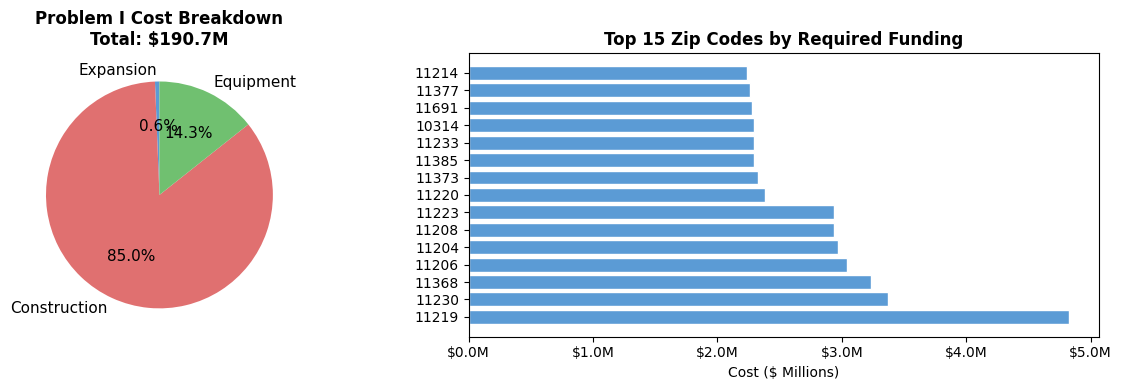

In [9]:
if m1.SolCount > 0:
    zip_cost1 = {}
    for z in Z:
        ec = sum(c_slots(n[i])*xlo_s[i] + slope_above(n[i])*xhi_s[i]
                 for i in zip_to_fac.get(z,[]))
        bc = sum(COST_NEW[s]*round(y1[z,s]) for s in SIZES)
        uc = EQUIP * sum(u1[z,s] for s in SIZES)
        zip_cost1[z] = ec + bc + uc

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].pie([ec1/1e6, bcc1/1e6, ucc1/1e6],
                labels=['Expansion', 'Construction', 'Equipment'],
                autopct='%1.1f%%', colors=['#5B9BD5','#E07070','#70C070'],
                startangle=90, textprops={'fontsize':11})
    axes[0].set_title(f'Problem I Cost Breakdown\nTotal: ${obj1/1e6:.1f}M', fontweight='bold')

    top15 = sorted(zip_cost1.items(), key=lambda kv: kv[1], reverse=True)[:15]
    z15, c15 = zip(*top15)
    axes[1].barh([str(z) for z in z15], [c/1e6 for c in c15],
                  color='#5B9BD5', edgecolor='white')
    axes[1].set_xlabel('Cost ($ Millions)')
    axes[1].set_title('Top 15 Zip Codes by Required Funding', fontweight='bold')
    axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.1f}M'))

    plt.tight_layout()
    plt.savefig('fig2_p1.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## Section 3 — Problem II: Realistic Expansion & Distance Constraints

### Changes from Problem I

**1. Hard 20% expansion cap** — $x_i \leq 0.20 \cdot n_i$. Facilities where $\lfloor 0.20 n_i \rfloor = 0$ are excluded.

**2. Convex piecewise-increasing cost** (3 segments, linearised with variables $x_i^{(1)}, x_i^{(2)}, x_i^{(3)}$):

| Segment | Range | Slope |
|---|---|---|
| 1 | $0 < x_i \leq 0.10 n_i$ | $(20000+200n_i)/n_i$ |
| 2 | $0.10n_i < x_i \leq 0.15n_i$ | $(20000+400n_i)/n_i$ |
| 3 | $0.15n_i < x_i \leq 0.20n_i$ | $(20000+1000n_i)/n_i$ |

Cost is convex-increasing so Gurobi fills cheaper segments first — no binary variables needed.

**3. Minimum distance (0.06 miles)** — sites within 0.06 mi of any existing facility are removed upfront; conflicting site pairs get mutual exclusion constraints.

In [10]:
def haversine(lat1, lon1, lat2, lon2):
    """Great-circle distance in miles."""
    R = 3958.8
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    a = sin((lat2-lat1)/2)**2 + cos(lat1)*cos(lat2)*sin((lon2-lon1)/2)**2
    return R * 2 * asin(sqrt(a))

MIN_DIST = 0.06  # miles

fac_coords = childcare[childcare['zipcode'].isin(Z)][['zipcode','latitude','longitude']]

feasible_sites = {}  # zip → list of (local_idx, lat, lon)
conflict_pairs = {}  # zip → list of (idx_a, idx_b) too-close pairs

for z in Z:
    existing   = fac_coords[fac_coords['zipcode']==z][['latitude','longitude']].values
    candidates = potential[potential['zipcode']==z][['latitude','longitude']].values

    valid = []
    for idx, (lat, lon) in enumerate(candidates):
        if all(haversine(lat,lon,e[0],e[1]) >= MIN_DIST for e in existing):
            valid.append((idx, lat, lon))
    feasible_sites[z] = valid

    pairs = []
    for ai in range(len(valid)):
        for bi in range(ai+1, len(valid)):
            _, la, lo = valid[ai]; _, lb, ob = valid[bi]
            if haversine(la,lo,lb,ob) < MIN_DIST:
                pairs.append((ai, bi))
    conflict_pairs[z] = pairs

# FIX 8: exclude facilities with effectively zero 20% expansion room
I2 = [i for i in I if int(0.20 * n[i]) >= 1]

print(f'Feasible new sites (post distance filter) : {sum(len(v) for v in feasible_sites.values()):,}')
print(f'Conflict pairs                             : {sum(len(v) for v in conflict_pairs.values()):,}')
print(f'Facilities in P2 expansion set             : {len(I2)} ({len(I)-len(I2)} excluded)')

Feasible new sites (post distance filter) : 15,193
Conflict pairs                             : 5,317
Facilities in P2 expansion set             : 7721 (4 excluded)


In [11]:
# ════════════════════════════════════════════════════════════
#  PROBLEM II — Gurobi MIP
# ════════════════════════════════════════════════════════════
m2 = gp.Model('ChildCare_P2_Realistic')
m2.Params.OutputFlag = 1
m2.Params.MIPGap     = 0.01

# ── Three-segment expansion variables ────────────────────────
x1 = m2.addVars(I2, lb=0, name='x1')   # [0,       0.10*n]
x2 = m2.addVars(I2, lb=0, name='x2')   # [0, 0.05*n]  (net: 0.10→0.15)
x3 = m2.addVars(I2, lb=0, name='x3')   # [0, 0.05*n]  (net: 0.15→0.20)

m2.addConstrs((x1[i] <= 0.10 * n[i] for i in I2), 'seg1')
m2.addConstrs((x2[i] <= 0.05 * n[i] for i in I2), 'seg2')
m2.addConstrs((x3[i] <= 0.05 * n[i] for i in I2), 'seg3')

x_total = {i: x1[i]+x2[i]+x3[i] for i in I2}

# ── Under-5 from expansion ───────────────────────────────────
a2 = m2.addVars(I2, lb=0, name='a2')
m2.addConstrs((a2[i] <= ratio_05[i] * x_total[i] for i in I2), 'a2_ratio')

# ── New facility binary variables (site-specific) ─────────────
y2_keys = [(z,j,s) for z in Z for j in range(len(feasible_sites[z])) for s in SIZES]
y2 = m2.addVars(y2_keys, vtype=GRB.BINARY, name='y2')

# At most one size per site
for z in Z:
    for j in range(len(feasible_sites[z])):
        m2.addConstr(gp.quicksum(y2[z,j,s] for s in SIZES) <= 1,
                     f'one_size_{z}_{j}')

# Distance: conflicting site pairs cannot both be chosen
for z in Z:
    for (ai, bi) in conflict_pairs[z]:
        m2.addConstr(
            gp.quicksum(y2[z,ai,s] for s in SIZES) +
            gp.quicksum(y2[z,bi,s] for s in SIZES) <= 1,
            f'dist_{z}_{ai}_{bi}'
        )

# ── Under-5 from new builds ──────────────────────────────────
u2 = m2.addVars(y2_keys, lb=0, name='u2')
m2.addConstrs(
    (u2[z,j,s] <= CAP_05[s] * y2[z,j,s] for (z,j,s) in y2_keys), 'u2_cap'
)

# ── Constraint 1: Desert elimination ─────────────────────────
m2.addConstrs(
    (gp.quicksum(x_total[i] for i in zip_to_fac.get(z,[]) if i in I2)
     + gp.quicksum(CAP_TOTAL[s]*y2[z,j,s]
                   for j in range(len(feasible_sites[z])) for s in SIZES)
     >= G[z]
     for z in Z if G[z] > 0),
    'desert_elim2'
)

# ── Constraint 2: Under-5 NYC policy ─────────────────────────
m2.addConstrs(
    (gp.quicksum(a2[i] for i in zip_to_fac.get(z,[]) if i in I2)
     + gp.quicksum(u2[z,j,s]
                   for j in range(len(feasible_sites[z])) for s in SIZES)
     >= G05[z]
     for z in Z if G05[z] > 0),
    'under5_cov2'
)

# ── Objective ─────────────────────────────────────────────────
exp_cost2 = gp.quicksum(
    (20_000+200*n[i])/n[i]   * x1[i] +
    (20_000+400*n[i])/n[i]   * x2[i] +
    (20_000+1000*n[i])/n[i]  * x3[i]
    for i in I2
)
build_cost2 = gp.quicksum(COST_NEW[s]*y2[z,j,s] for (z,j,s) in y2_keys)
equip_cost2 = EQUIP * gp.quicksum(u2[z,j,s] for (z,j,s) in y2_keys)

m2.setObjective(exp_cost2 + build_cost2 + equip_cost2, GRB.MINIMIZE)
m2.optimize()

Set parameter OutputFlag to value 1
Set parameter MIPGap to value 0.01
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 24.6.0 24G517)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Non-default parameters:
MIPGap  0.01

Optimize a model with 97311 rows, 122042 columns and 333814 nonzeros (Min)
Model fingerprint: 0xb9505acb
Model has 114321 linear objective coefficients
Variable types: 76463 continuous, 45579 integer (45579 binary)
Coefficient statistics:
  Matrix range     [2e-02, 4e+02]
  Objective range  [1e+02, 1e+05]
  Bounds range     [1e+00, 1e+00]
  RHS range        [2e-01, 1e+04]

Presolve removed 62594 rows and 64897 columns
Presolve time: 3.39s
Presolved: 34717 rows, 57145 columns, 142420 nonzeros
Variable types: 25465 continuous, 31680 integer (27525 binary)
Found heuristic solution: objective 5.712522e+08
Found heuristic solution: objective 5.570672e+08
Deterministic concurrent LP optimizer: primal a

In [12]:
if m2.SolCount == 0:
    print('No feasible solution found for Problem II.')
else:
    obj2 = m2.ObjVal

    exp2_sl = sum(x1[i].X+x2[i].X+x3[i].X for i in I2)
    n2_exp  = sum(1 for i in I2 if x1[i].X+x2[i].X+x3[i].X > 0.5)

    bc2 = {s: sum(round(y2[z,j,s].X) for z in Z for j in range(len(feasible_sites[z]))) for s in SIZES}
    bsl2 = sum(CAP_TOTAL[s]*round(y2[z,j,s].X) for (z,j,s) in y2_keys)
    new_u052 = sum(u2[z,j,s].X for (z,j,s) in y2_keys)
    exp_u052 = sum(a2[i].X for i in I2)

    ec2  = sum((20000+200*n[i])/n[i]*x1[i].X + (20000+400*n[i])/n[i]*x2[i].X +
               (20000+1000*n[i])/n[i]*x3[i].X for i in I2)
    bcc2 = sum(COST_NEW[s]*round(y2[z,j,s].X) for (z,j,s) in y2_keys)
    ucc2 = EQUIP * new_u052

    print('=' * 57)
    print('  PROBLEM II — REALISTIC SCENARIO RESULTS')
    print('=' * 57)
    print(f'  Minimum total funding         : ${obj2:>15,.2f}')
    print(f'  ─ Expansion cost              : ${ec2:>15,.2f}')
    print(f'  ─ Construction cost           : ${bcc2:>15,.2f}')
    print(f'  ─ Equipment cost (0-5 slots)  : ${ucc2:>15,.2f}')
    print(f'  Slots via expansion           : {exp2_sl:>15,.0f}')
    print(f'  Facilities expanded           : {n2_exp:>15,}')
    print(f'  Slots via new builds          : {bsl2:>15,}')
    print(f'  New facilities (Small/100)    : {bc2["S"]:>15,}')
    print(f'  New facilities (Medium/200)   : {bc2["M"]:>15,}')
    print(f'  New facilities (Large/400)    : {bc2["L"]:>15,}')
    print(f'  Under-5 slots (new builds)    : {new_u052:>15,.0f}')
    print(f'  Under-5 slots (expansion)     : {exp_u052:>15,.0f}')

  PROBLEM II — REALISTIC SCENARIO RESULTS
  Minimum total funding         : $ 192,099,564.60
  ─ Expansion cost              : $     979,764.71
  ─ Construction cost           : $ 163,780,000.00
  ─ Equipment cost (0-5 slots)  : $  27,339,800.00
  Slots via expansion           :             674
  Facilities expanded           :             371
  Slots via new builds          :         566,200
  New facilities (Small/100)    :              12
  New facilities (Medium/200)   :              15
  New facilities (Large/400)    :           1,405
  Under-5 slots (new builds)    :         273,398
  Under-5 slots (expansion)     :             493


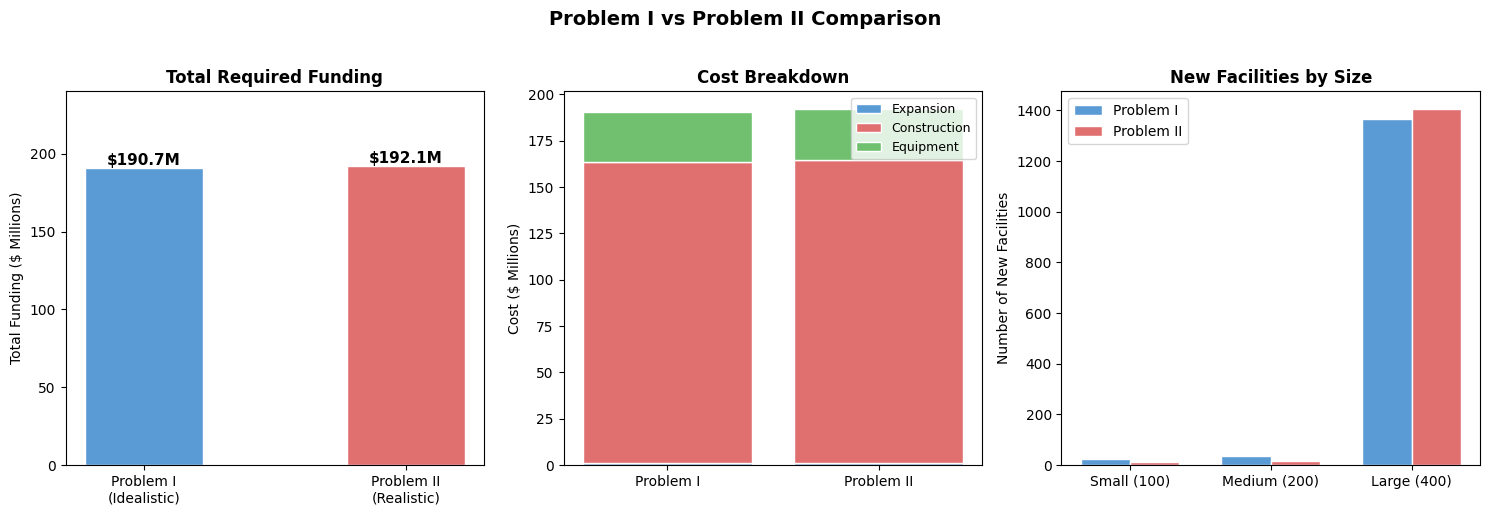

In [13]:
if m1.SolCount > 0 and m2.SolCount > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # 1. Total funding
    axes[0].bar(['Problem I\n(Idealistic)', 'Problem II\n(Realistic)'],
                [obj1/1e6, obj2/1e6], color=['#5B9BD5','#E07070'],
                edgecolor='white', width=0.45)
    for i, v in enumerate([obj1/1e6, obj2/1e6]):
        axes[0].text(i, v*1.01, f'${v:.1f}M', ha='center', fontweight='bold', fontsize=11)
    axes[0].set_ylabel('Total Funding ($ Millions)')
    axes[0].set_title('Total Required Funding', fontweight='bold')
    axes[0].set_ylim(0, max(obj1,obj2)/1e6 * 1.25)

    # 2. Cost breakdown stacked bar
    cats = ['Problem I', 'Problem II']
    exp_vals   = [ec1/1e6,  ec2/1e6]
    build_vals = [bcc1/1e6, bcc2/1e6]
    equip_vals = [ucc1/1e6, ucc2/1e6]
    axes[1].bar(cats, exp_vals,   label='Expansion',     color='#5B9BD5', edgecolor='white')
    axes[1].bar(cats, build_vals, label='Construction',  color='#E07070', edgecolor='white',
                bottom=exp_vals)
    axes[1].bar(cats, equip_vals, label='Equipment',     color='#70C070', edgecolor='white',
                bottom=[e+b for e,b in zip(exp_vals, build_vals)])
    axes[1].set_ylabel('Cost ($ Millions)')
    axes[1].set_title('Cost Breakdown', fontweight='bold')
    axes[1].legend(fontsize=9)

    # 3. New facilities by size
    xp = np.arange(3); w = 0.35
    axes[2].bar(xp-w/2, [bc1[s]  for s in SIZES], w, label='Problem I',  color='#5B9BD5', edgecolor='white')
    axes[2].bar(xp+w/2, [bc2[s] for s in SIZES], w,  label='Problem II', color='#E07070', edgecolor='white')
    axes[2].set_xticks(xp)
    axes[2].set_xticklabels(['Small (100)', 'Medium (200)', 'Large (400)'])
    axes[2].set_ylabel('Number of New Facilities')
    axes[2].set_title('New Facilities by Size', fontweight='bold')
    axes[2].legend()

    plt.suptitle('Problem I vs Problem II Comparison', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('fig3_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## Conclusions

**Key findings:**

- **160 of 179 active zip codes** are child care deserts. An additional **18 non-desert zips** fail the NYC under-5 policy independently — this constraint is separately binding and must not be omitted.
- **Correct 0-5 slot counting** is critical: FDC/GFDC facilities store all capacity in `children_capacity`, not in the age-specific columns. Counting only `infant + toddler + preschool` understates existing 0-5 availability by ~130× and inflates the under-5 gap.
- **Problem II** costs more than Problem I due to: (a) the 20% expansion hard cap limiting what existing facilities can contribute, and (b) the 0.06-mile distance rule restricting new-build placement — particularly binding in dense neighborhoods.
- Large facilities ($115k / 400 slots) dominate new builds in both problems because they have the lowest cost-per-slot ratio ($287.50/slot vs. $650/slot for Small).
- **4 zip codes** (10018, 10162, 11005, 11697) have no existing facilities and depend entirely on new construction.